# Multinomial Classifications

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import  cross_val_predict
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from xgboost import XGBClassifier

In [2]:
mnist = fetch_openml("mnist_784", as_frame=False)

xTrain, yTrain, xTest, yTest = mnist.data[:60000], mnist.target[:60000].astype(np.int8), mnist.data[60000:], mnist.target[60000:].astype(np.int8)
xTrain, yTrain, xTest, yTest

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784)),
 array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=int8),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784)),
 array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=int8))

In [3]:
xGBCModel = XGBClassifier(
    tree_method="hist",
    n_jobs=11,
    eval_metric="mlogloss",
    random_state=42,
    learning_rate = 0.03,
    n_estimators= 1600,
    )

In [4]:
crosPredictions = cross_val_predict(xGBCModel, xTrain, yTrain, cv=5, n_jobs=11)

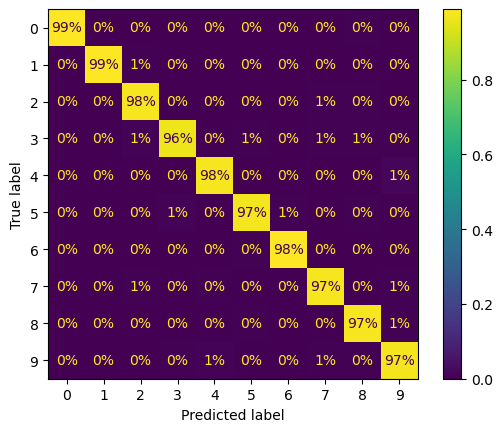

In [5]:
ConfusionMatrixDisplay.from_predictions(yTrain, crosPredictions, normalize="true", values_format=".0%")
plt.show()

In [6]:
accuracy_score(yTrain, crosPredictions)

0.9769833333333333

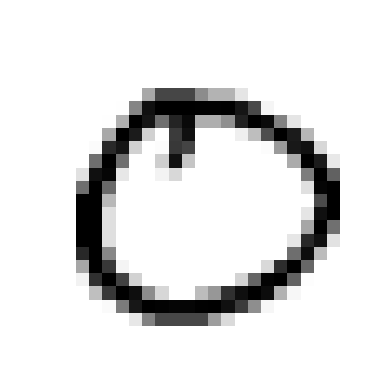

Ai detects: 0


In [7]:
randomIndex = np.random.randint(low=0, high=60000)
plt.imshow(xTrain[randomIndex].reshape(28,28), cmap="binary")
plt.axis("off")
plt.show()
print(f"Ai detects: {crosPredictions[randomIndex]}")